In [2]:
import pyarrow.feather as feather

tbl = feather.read_table("cosmos_subset.feather", memory_map=True)
df = tbl.to_pandas(ignore_metadata=True)

In [3]:
df.columns

Index(['ID', 'ALPHA_J2000', 'DELTA_J2000', 'X_IMAGE', 'Y_IMAGE', 'ERRX2_IMAGE',
       'ERRY2_IMAGE', 'ERRXY_IMAGE', 'FLUX_RADIUS', 'KRON_RADIUS',
       ...
       'ez_ssfr_p025', 'ez_ssfr_p160', 'ez_ssfr_p500', 'ez_ssfr_p840',
       'ez_ssfr_p975', 'ez_Av_p025', 'ez_Av_p160', 'ez_Av_p500', 'ez_Av_p840',
       'ez_Av_p975'],
      dtype='object', length=754)

In [79]:
df1=df.loc[:, df.columns.str.contains('FLUX_APER2')]

In [80]:
df1['SPLASH_CH1_FLUXERR']=df['SPLASH_CH1_FLUX']

C:\Users\pranav\AppData\Local\Temp\ipykernel_35508\1583277818.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['SPLASH_CH1_FLUXERR']=df['SPLASH_CH1_FLUX']


In [81]:
df_err=df.loc[:, df.columns.str.contains('FLUXERR_APER2')]

In [82]:
df_err['ACS_F814W_FLUXERR']=df['ACS_F814W_FLUXERR']

C:\Users\pranav\AppData\Local\Temp\ipykernel_35508\76723969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_err['ACS_F814W_FLUXERR']=df['ACS_F814W_FLUXERR']


In [84]:
df_err


,CFHT_u_FLUXERR_APER2,CFHT_ustar_FLUXERR_APER2,HSC_g_FLUXERR_APER2,HSC_r_FLUXERR_APER2,HSC_i_FLUXERR_APER2,HSC_z_FLUXERR_APER2,HSC_y_FLUXERR_APER2,UVISTA_Y_FLUXERR_APER2,UVISTA_J_FLUXERR_APER2,UVISTA_H_FLUXERR_APER2,...,SC_NB816_FLUXERR_APER2,UVISTA_NB118_FLUXERR_APER2,SC_B_FLUXERR_APER2,SC_gp_FLUXERR_APER2,SC_V_FLUXERR_APER2,SC_rp_FLUXERR_APER2,SC_ip_FLUXERR_APER2,SC_zp_FLUXERR_APER2,SC_zpp_FLUXERR_APER2,ACS_F814W_FLUXERR
0,0.010909,NaN,0.123257,0.184755,0.200347,0.282025,0.354773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.045224,NaN,0.128492,0.131761,0.116808,0.169952,0.285746,NaN,NaN,NaN,...,0.003297,NaN,0.000453,NaN,NaN,0.000703,NaN,0.001237,NaN,NaN
2,0.003934,NaN,0.018433,0.027381,0.031572,0.041004,0.056987,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.008416,0.010024,0.007664,0.012334,0.012884,0.021770,0.045280,NaN,NaN,NaN,...,0.194156,NaN,0.043398,0.193260,0.082101,0.055827,NaN,0.206653,NaN,NaN
4,0.010576,0.012348,0.007439,0.010646,0.015092,0.024029,0.058031,NaN,NaN,NaN,...,0.190927,NaN,0.045352,0.358231,0.087019,0.058790,NaN,0.231124,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720695,0.009446,0.022091,0.008970,0.011224,0.015534,0.023729,0.061769,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720696,0.009407,0.022465,NaN,NaN,0.000326,NaN,0.001353,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720697,0.009412,0.021828,NaN,NaN,0.000135,NaN,0.002140,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720698,0.009399,0.021966,NaN,NaN,0.000389,NaN,0.001898,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
df1 = df1.fillna(0)


In [149]:
df1 = pd.read_feather("cosmos_filter.feather")

In [151]:
import numpy as np
import matplotlib.pyplot as plt
p=[]
for i in df1.columns:
    m = 23.9-2.5*np.log10(df1[i]) 
    m = m[np.isfinite(m)]   # remove NaN/inf
    counts, bins, patches = plt.hist(m, bins=100)
    imax = counts.argmax()
    p.append(0.5 * (bins[imax] + bins[imax+1]))
    plt.clf()  


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Figure size 640x480 with 0 Axes>

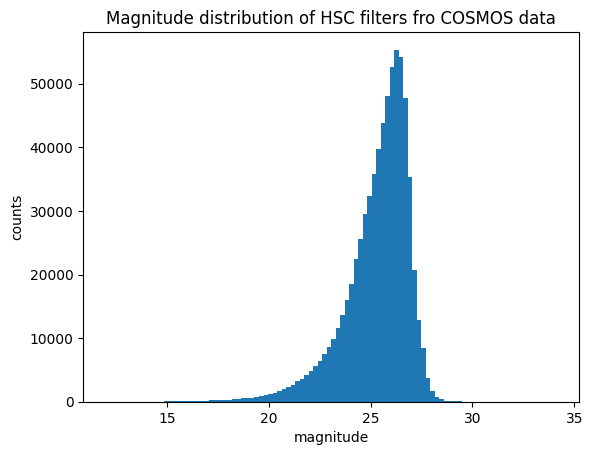

In [152]:
plt.hist(m,bins=100)
plt.title('Magnitude distribution of HSC filters fro COSMOS data')
plt.xlabel("magnitude")
plt.ylabel('counts')
plt.show()

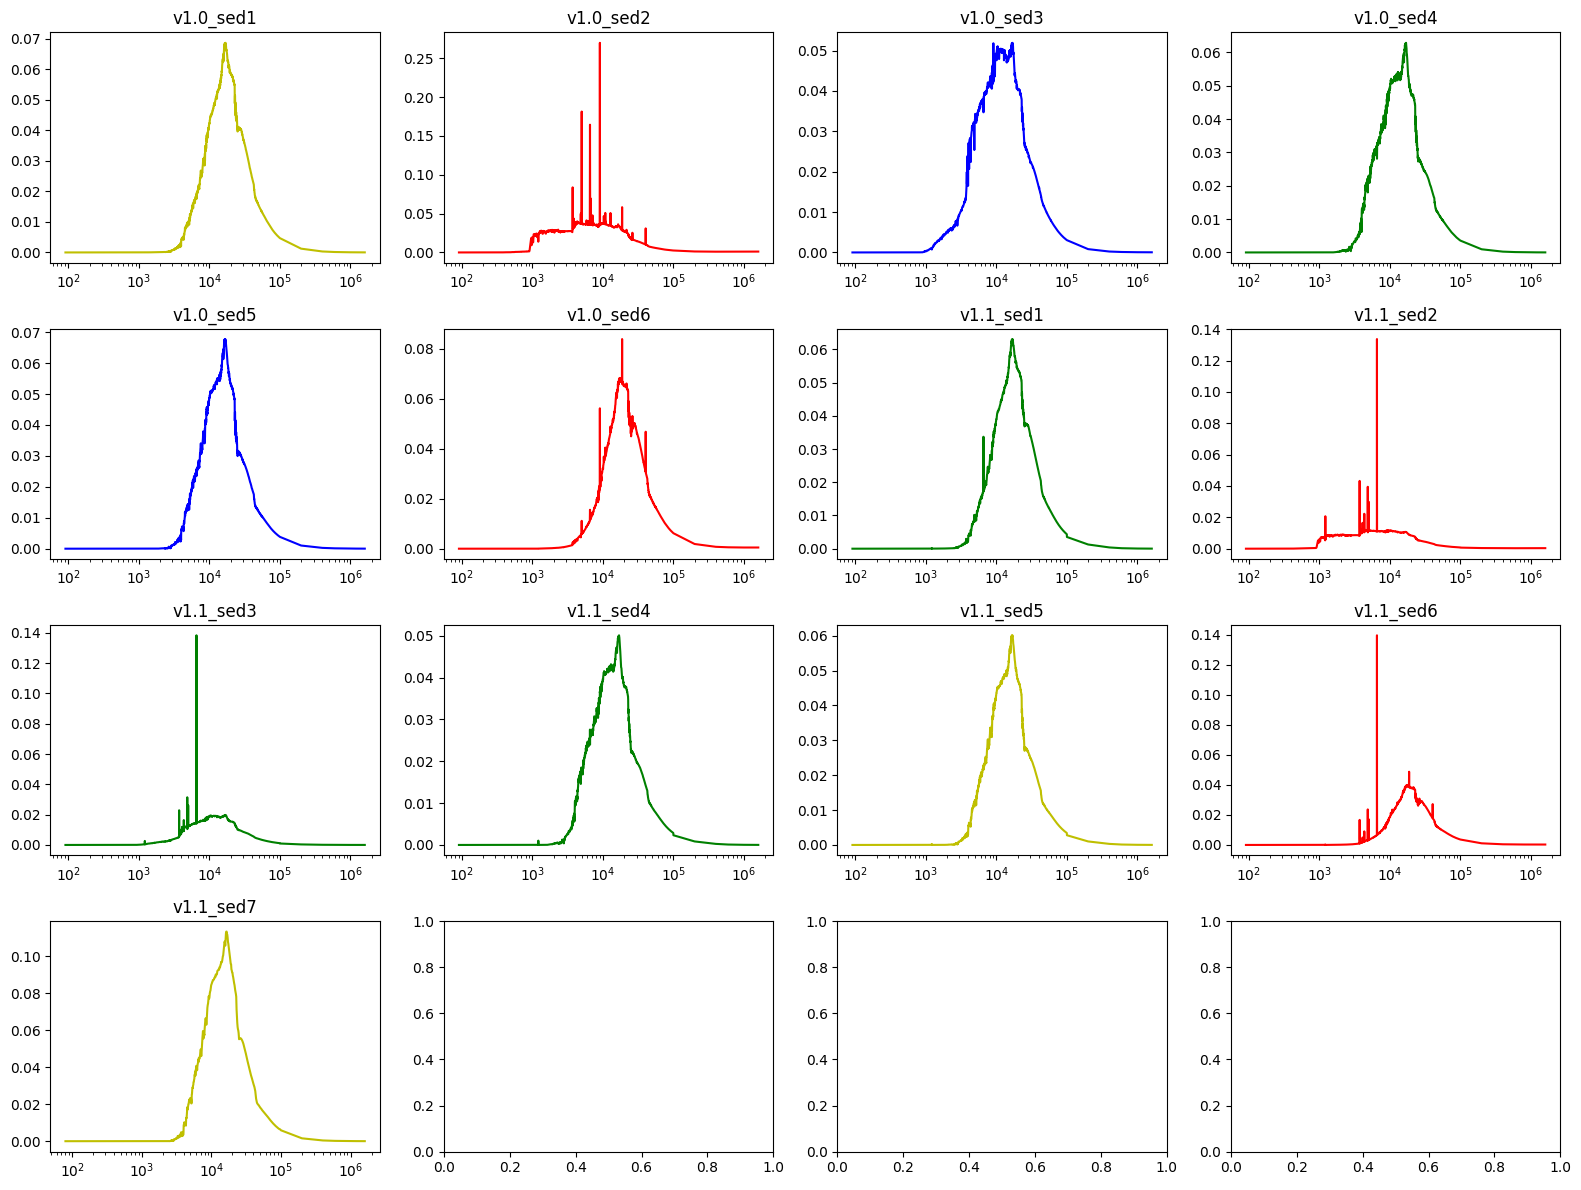

In [4]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
f=glob('eazy*')
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
p=['r','b','g','y']
wave1={}
norm_flux1={}
for idx, i in enumerate(f):
    wave, flux = np.loadtxt(i, unpack=True)
    flux *= wave**2. / 3e18
    norm=np.sqrt(np.sum(flux**2))
    norm_flux=flux/norm
    wave1[i]=wave
    norm_flux1[i]=norm_flux
    ax = axes[idx]
    ax.plot(wave, norm_flux,color=np.random.choice(p))
    ax.set_title(i[-13:-4])
    #ax.set_xlim(0,20000)
    ax.set_xscale('log')




plt.tight_layout()
plt.show()


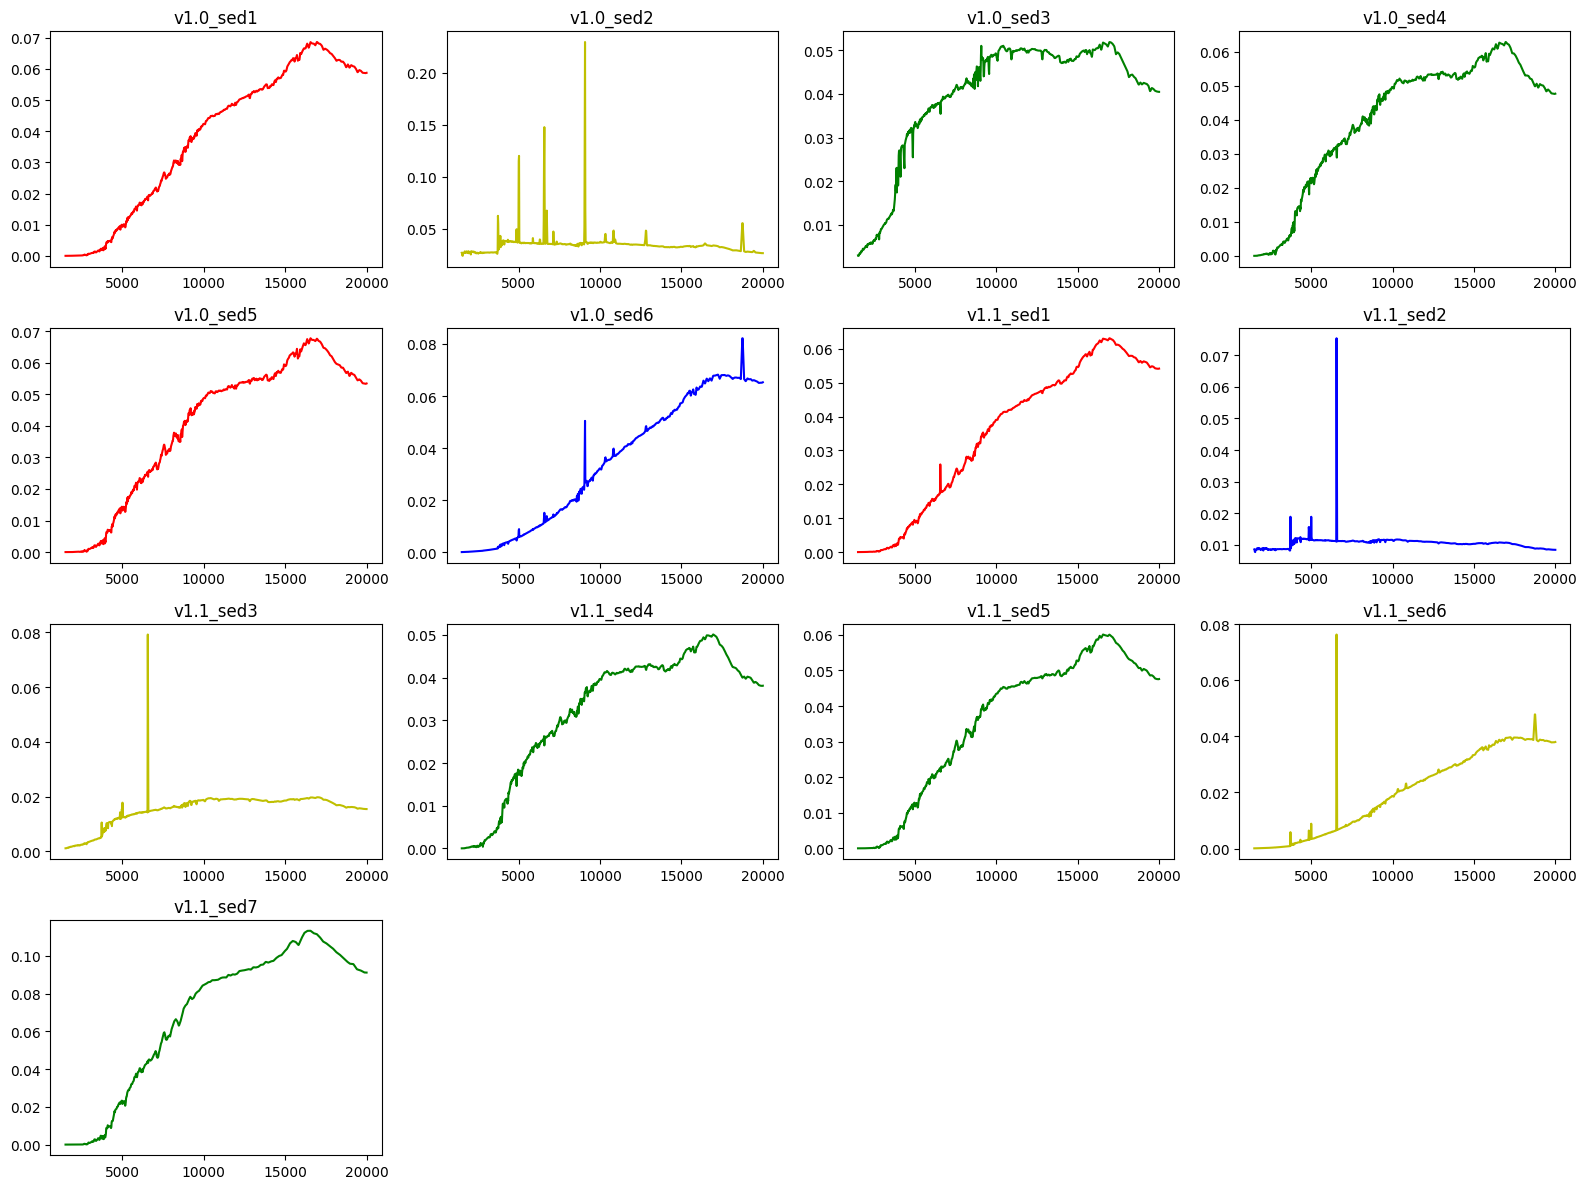

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
p=['r','b','g','y']
wave_grid = np.linspace(1500, 20000, 1000)
norm_flux_interp={}
for idx, i in enumerate(wave1.keys()):
    norm_flux_int = np.interp(wave_grid, wave1[i], norm_flux1[i])
    norm_flux_interp[i]=norm_flux_int
    ax = axes[idx]
    ax.plot(wave_grid, norm_flux_int,color=np.random.choice(p))
    ax.set_title(i[-13:-4])
    #ax.set_xscale('log')

for idx in range(len(f), len(axes)):
    axes[idx].axis('off')


plt.tight_layout()
plt.show()

In [6]:
flux_list = []
for name in norm_flux_interp.keys():
    flux_list.append(norm_flux_interp[name])

data_matrix = np.array(flux_list)

from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(data_matrix)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [7]:
import pandas as pd
df = pd.read_feather("cosmos_used_filter.feather")
df_err=pd.read_feather("cosmos_used_error.feather")

# Normalized Residuals

In [8]:
fil=['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484','subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','subaru_suprimecam_ip','subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

In [47]:
import pickle
with open('LS_coeff.pkl', 'rb') as file:
        B = pickle.load(file)

In [11]:
df=df.drop('X_IMAGE',axis=1)

In [12]:
B.shape,df.shape,df_err.shape

((1720700, 4), (1720700, 23), (1720700, 23))

In [13]:
df.columns,df_err.columns

(Index(['GALEX_NUV_FLUX', 'GALEX_FUV_FLUX', 'HSC_g_FLUX_APER2',
        'HSC_r_FLUX_APER2', 'HSC_i_FLUX_APER2', 'HSC_z_FLUX_APER2',
        'HSC_y_FLUX_APER2', 'SC_B_FLUX_APER2', 'SC_V_FLUX_APER2',
        'SC_IA484_FLUX_APER2', 'SC_IA527_FLUX_APER2', 'SC_IA624_FLUX_APER2',
        'SC_IA679_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
        'SC_ip_FLUX_APER2', 'SC_zp_FLUX_APER2', 'SC_rp_FLUX_APER2',
        'UVISTA_H_FLUX_APER2', 'UVISTA_J_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
        'UVISTA_Ks_FLUX_APER2', 'ACS_F814W_FLUX'],
       dtype='object'),
 Index(['GALEX_NUV_FLUXERR', 'GALEX_FUV_FLUXERR', 'HSC_g_FLUXERR_APER2',
        'HSC_r_FLUXERR_APER2', 'HSC_i_FLUXERR_APER2', 'HSC_z_FLUXERR_APER2',
        'HSC_y_FLUXERR_APER2', 'SC_B_FLUXERR_APER2', 'SC_V_FLUXERR_APER2',
        'SC_IA484_FLUXERR_APER2', 'SC_IA527_FLUXERR_APER2',
        'SC_IA624_FLUXERR_APER2', 'SC_IA679_FLUXERR_APER2',
        'SC_IA738_FLUXERR_APER2', 'SC_IA767_FLUXERR_APER2',
        'SC_ip_FLUXERR_

In [14]:
df.shape
y

NameError: name 'y' is not defined

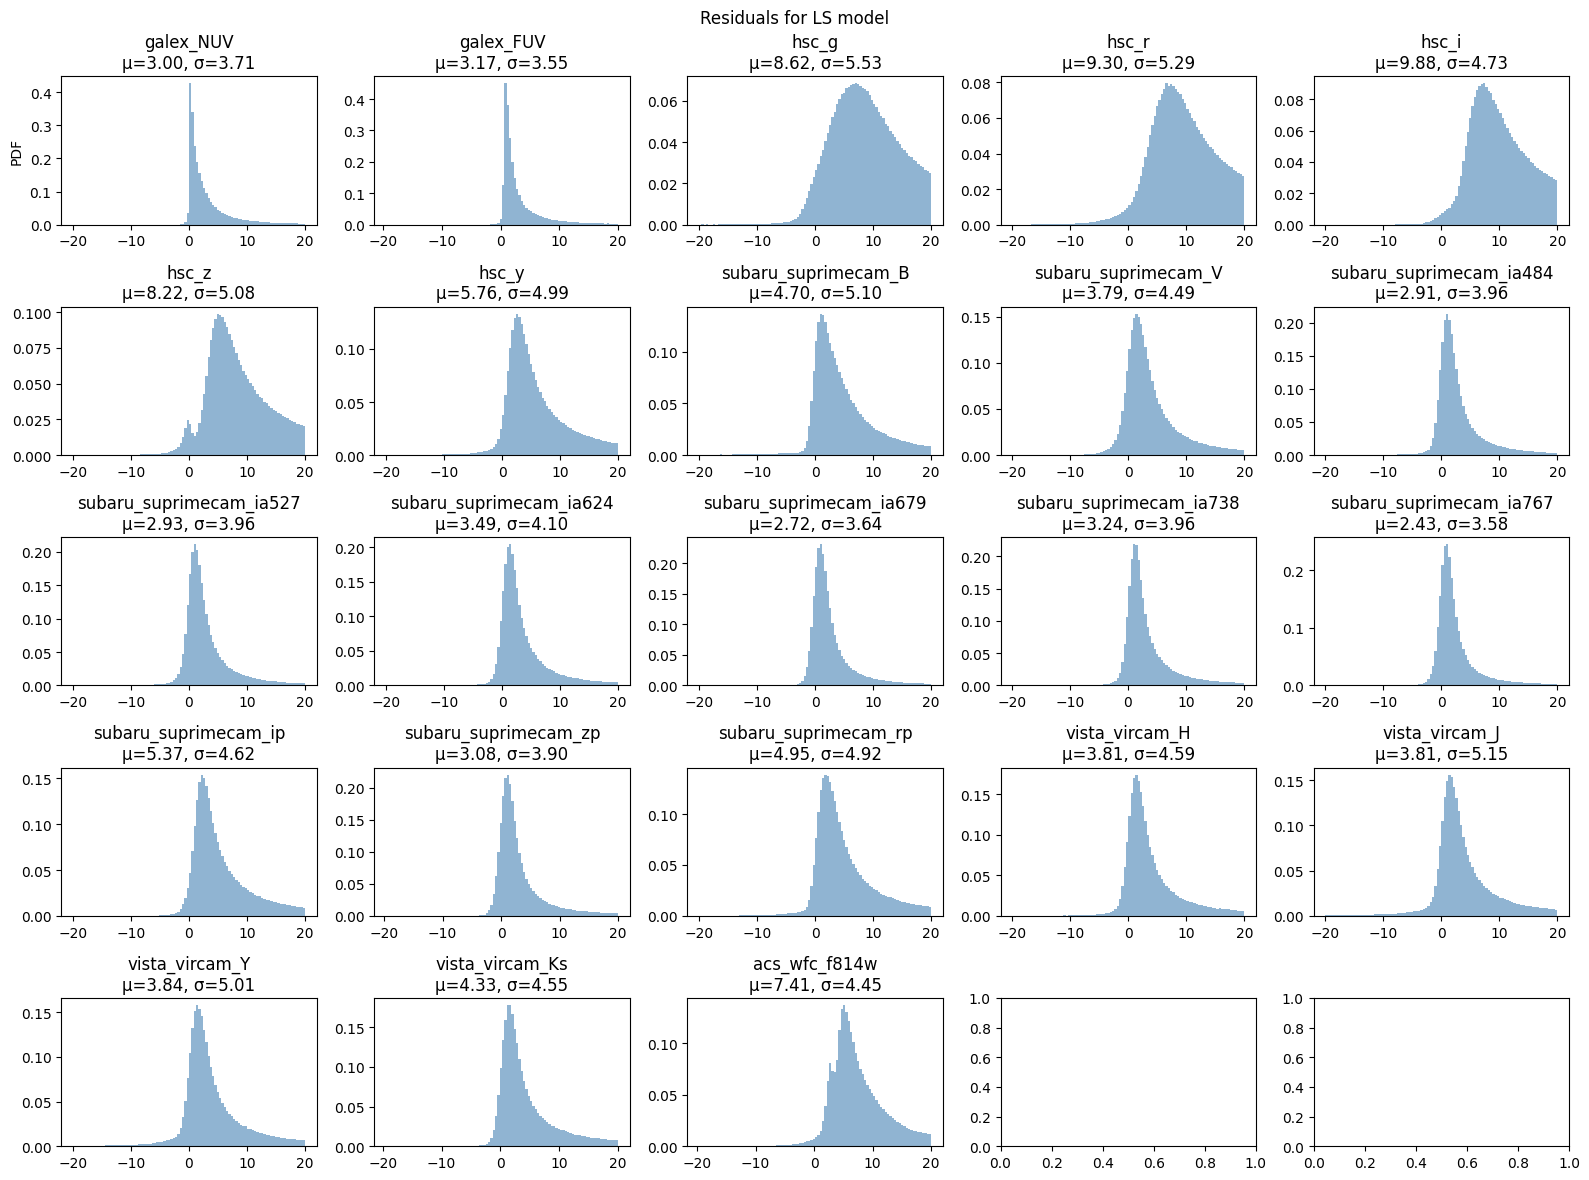

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()

n_gal, n_bands = df.shape

# Precompute once
A = X   # (n_bands, n_coeff)
model_flux_all = B @ A   # (n_galaxies, n_bands)

for i in range(n_bands):
    data  = df.iloc[:, i].to_numpy()
    error = df_err.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error)
    data, error = data[mask], error[mask]
    model = model_flux_all[mask, i]

    # Normalized residuals
    r = (data - model) / error
    r_clip = r[np.abs(r) < 20]

    ax = axes[i]
    ax.hist(r_clip, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r_clip), np.std(r_clip)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for LS model')
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
df_b = pd.read_feather("cosmos_filter.feather")

In [39]:
df_berr.columns

Index(['CFHT_u_FLUXERR_APER2', 'CFHT_ustar_FLUXERR_APER2',
       'SC_IB427_FLUXERR_APER2', 'SC_IB464_FLUXERR_APER2',
       'SC_IB505_FLUXERR_APER2', 'SC_IB574_FLUXERR_APER2',
       'SC_IB709_FLUXERR_APER2', 'SC_IB827_FLUXERR_APER2',
       'SC_NB711_FLUXERR_APER2', 'SC_NB816_FLUXERR_APER2',
       'UVISTA_NB118_FLUXERR_APER2', 'SC_gp_FLUXERR_APER2',
       'SC_zpp_FLUXERR_APER2', 'IRAC_CH1_FLUXERR', 'SPLASH_CH1_FLUXERR'],
      dtype='object')

In [23]:
df.columns

Index(['GALEX_NUV_FLUX', 'GALEX_FUV_FLUX', 'HSC_g_FLUX_APER2',
       'HSC_r_FLUX_APER2', 'HSC_i_FLUX_APER2', 'HSC_z_FLUX_APER2',
       'HSC_y_FLUX_APER2', 'SC_B_FLUX_APER2', 'SC_V_FLUX_APER2',
       'SC_IA484_FLUX_APER2', 'SC_IA527_FLUX_APER2', 'SC_IA624_FLUX_APER2',
       'SC_IA679_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
       'SC_ip_FLUX_APER2', 'SC_zp_FLUX_APER2', 'SC_rp_FLUX_APER2',
       'UVISTA_H_FLUX_APER2', 'UVISTA_J_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
       'UVISTA_Ks_FLUX_APER2', 'ACS_F814W_FLUX'],
      dtype='object')

In [24]:
for i in df_b.columns:
    if i in df.columns:
        df_b=df_b.drop(i,axis=1)

In [26]:
df_err.columns

Index(['GALEX_NUV_FLUXERR', 'GALEX_FUV_FLUXERR', 'HSC_g_FLUXERR_APER2',
       'HSC_r_FLUXERR_APER2', 'HSC_i_FLUXERR_APER2', 'HSC_z_FLUXERR_APER2',
       'HSC_y_FLUXERR_APER2', 'SC_B_FLUXERR_APER2', 'SC_V_FLUXERR_APER2',
       'SC_IA484_FLUXERR_APER2', 'SC_IA527_FLUXERR_APER2',
       'SC_IA624_FLUXERR_APER2', 'SC_IA679_FLUXERR_APER2',
       'SC_IA738_FLUXERR_APER2', 'SC_IA767_FLUXERR_APER2',
       'SC_ip_FLUXERR_APER2', 'SC_zp_FLUXERR_APER2', 'SC_rp_FLUXERR_APER2',
       'UVISTA_H_FLUXERR_APER2', 'UVISTA_J_FLUXERR_APER2',
       'UVISTA_Y_FLUXERR_APER2', 'UVISTA_Ks_FLUXERR_APER2',
       'ACS_F814W_FLUXERR'],
      dtype='object')

In [27]:
df_berr = pd.read_feather("cosmos_error.feather")

In [28]:
for i in df_berr.columns:
    if i in df_err.columns:
        df_berr=df_berr.drop(i,axis=1)

In [58]:
df_berr=df_berr.drop(['CFHT_ustar_FLUXERR_APER2','SPLASH_CH1_FLUXERR'],axis=1)

In [30]:
from sedpy.observate import Filter

filter_files = ['CFHT_MegaCam.u.dat','Subaru_Suprime.IB427.dat','Subaru_Suprime.IB464.dat','Subaru_Suprime.IB505.dat','Subaru_Suprime.IB574.dat','Subaru_Suprime.IB709.dat','Subaru_Suprime.IB827.dat','Subaru_Suprime.NB711.dat','HSC-NB816.txt','Paranal_VISTA.NB118.dat','HSC-gp.txt','zpp.res','irac_ch1.res']
filters = [Filter(filename=f) for f in filter_files]

In [31]:
import pickle
with open('XD_coeff.pkl', 'rb') as file:
        C = pickle.load(file)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
filt = load_filters(fil)
X = getSED(wave_grid, H, filters, linear_flux=True) * 3631 * 1e6 
n_gal, n_bands = df_b.shape

# Precompute once
A = X   # (n_bands, n_coeff)
model_flux_all = B @ A   # (n_galaxies, n_bands)

for i in range(n_bands-1):
    data  = df_b.iloc[:, i].to_numpy()
    error = df_berr.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error)
    data, error = data[mask], error[mask]
    model = model_flux_all[mask, i]

    # Normalized residuals
    r = (data - model) / error
    r_clip = r[np.abs(r) < 20]

    ax = axes[i]
    ax.hist(r_clip, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r_clip), np.std(r_clip)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for XD model')
plt.tight_layout()
plt.show()


In [16]:
mean_prior=[ 3.04611263e-18 ,-1.61108748e-18,  1.16478862e-17, -2.93271070e-18]

cov_prior=[[ 1.84662957e-32 ,-1.88661604e-32 , 1.73518151e-32, -4.61214419e-33],
 [-1.88661604e-32 , 2.96753379e-32 ,-3.42471453e-32,  7.68685080e-33],
 [ 1.73518151e-32 ,-3.42471453e-32,  1.25035052e-31 ,-7.62951815e-32],
 [-4.61214419e-33 , 7.68685080e-33, -7.62951815e-32 , 6.17592383e-32]]

In [18]:
import numpy as np
from sedpy.observate import load_filters, getSED

# --------------------------------------------------
# Inputs
# --------------------------------------------------

# wave_grid : 1D array of wavelengths in Angstroms
# H : 2D array of PCA SEDs, shape (n_coeff, n_wave)
# fil : list of filter names compatible with sedpy
# Example: fil = ['hsc_g', 'hsc_r', 'hsc_i', 'hsc_z', 'hsc_y', 'vista_vircam_J']

filters = load_filters(fil)      # load all filters at once

# --------------------------------------------------
# Compute A matrix
# --------------------------------------------------

# Each column = PCA component, each row = filter
# getSED expects (wave, spec, filters)
A = np.array([
    getSED(wave_grid, H_k, filters, linear_flux=True) 
    for H_k in H
]).T   # shape → (n_bands, n_coeff)

# Optional: convert from Jy to microJy if needed (depends on your units)
A *= 3631 * 1e6

print(f"A.shape = {A.shape}")   # (n_bands, n_coeff)


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, resource_listdir


A.shape = (23, 4)


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [205]:

import numpy as np
mu = mean_prior # shape (n_coeff,) 
Sigma = cov_prior # shape (n_coeff, n_coeff)
# Precompute constants
Sigma_inv = np.linalg.inv(Sigma)
                   # shape (n_bands, n_coeff)
AT = A.T                         # (n_coeff, n_bands)
n_bands, n_coeff = A.shape

# Prepare data arrays
Y = df.to_numpy(float) 
Y = np.nan_to_num(Y, nan=0.0)
# (N_galaxies, n_bands)
E = df_err.to_numpy(float)  
E = np.nan_to_num(E, nan=1e6)
# (N_galaxies, n_bands)

# Compute 1/sigma^2 for each galaxy-band pair
W = 1.0 / (E**2)         # avoid divide by zero

# Precompute A^T Σ_inv_A (same for all galaxies if A fixed)
Sigma_inv_term = Sigma_inv

# For speed, precompute A^T once
AT = A.T

# Initialize coefficient array
N = Y.shape[0]
coeffs = np.empty((N, n_coeff))

for i in range(N):
    w = W[i]                             # (n_bands,)
    y = Y[i]                             # (n_bands,)

    # Weighted design matrix
    Aw = A * w[:, None]                  # (n_bands, n_coeff)
    AT_Sinv_A = AT @ Aw                  # (n_coeff, n_coeff)
    AT_Sinv_y = AT @ (w * y)             # (n_coeff,)

    C = np.linalg.inv(Sigma_inv_term + AT_Sinv_A)
    m = C @ (Sigma_inv_term @ mu + AT_Sinv_y)
    coeffs[i] = m



In [220]:
import pickle
with open('XD_coeff.pkl', 'wb') as f:
    pickle.dump(coeffs, f)

In [222]:
coeffs

array([[-1.65042762e-16,  1.10284463e-15,  8.55552230e-16,
         2.45875755e-16],
       [ 9.15285126e-16, -1.32542102e-15,  3.27466704e-15,
        -1.93454767e-15],
       [-1.32492313e-17,  2.83009931e-17,  3.53941984e-17,
        -7.91194809e-18],
       ...,
       [ 1.04977665e-18, -9.25663754e-19, -8.29094662e-18,
         1.08233396e-17],
       [ 9.94540751e-19, -8.86628144e-19, -8.28998665e-18,
         1.08189564e-17],
       [ 2.17869085e-18, -1.70251013e-18, -7.70569483e-18,
         1.04920294e-17]])

In [182]:
A = getSED(wave_grid, H, filters, linear_flux=True) * 3631 * 1e6   


['galex_NUV',
 'galex_FUV',
 'hsc_g',
 'hsc_r',
 'hsc_i',
 'hsc_z',
 'hsc_y',
 'subaru_suprimecam_B',
 'subaru_suprimecam_V',
 'subaru_suprimecam_ia484',
 'subaru_suprimecam_ia527',
 'subaru_suprimecam_ia624',
 'subaru_suprimecam_ia679',
 'subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767',
 'subaru_suprimecam_ip',
 'subaru_suprimecam_zp',
 'subaru_suprimecam_rp',
 'vista_vircam_H',
 'vista_vircam_J',
 'vista_vircam_Y',
 'vista_vircam_Ks',
 'acs_wfc_f814w']

In [19]:
filt = load_filters(fil)
X = getSED(wave_grid, H, filt, linear_flux=True) * 3631 * 1e6 

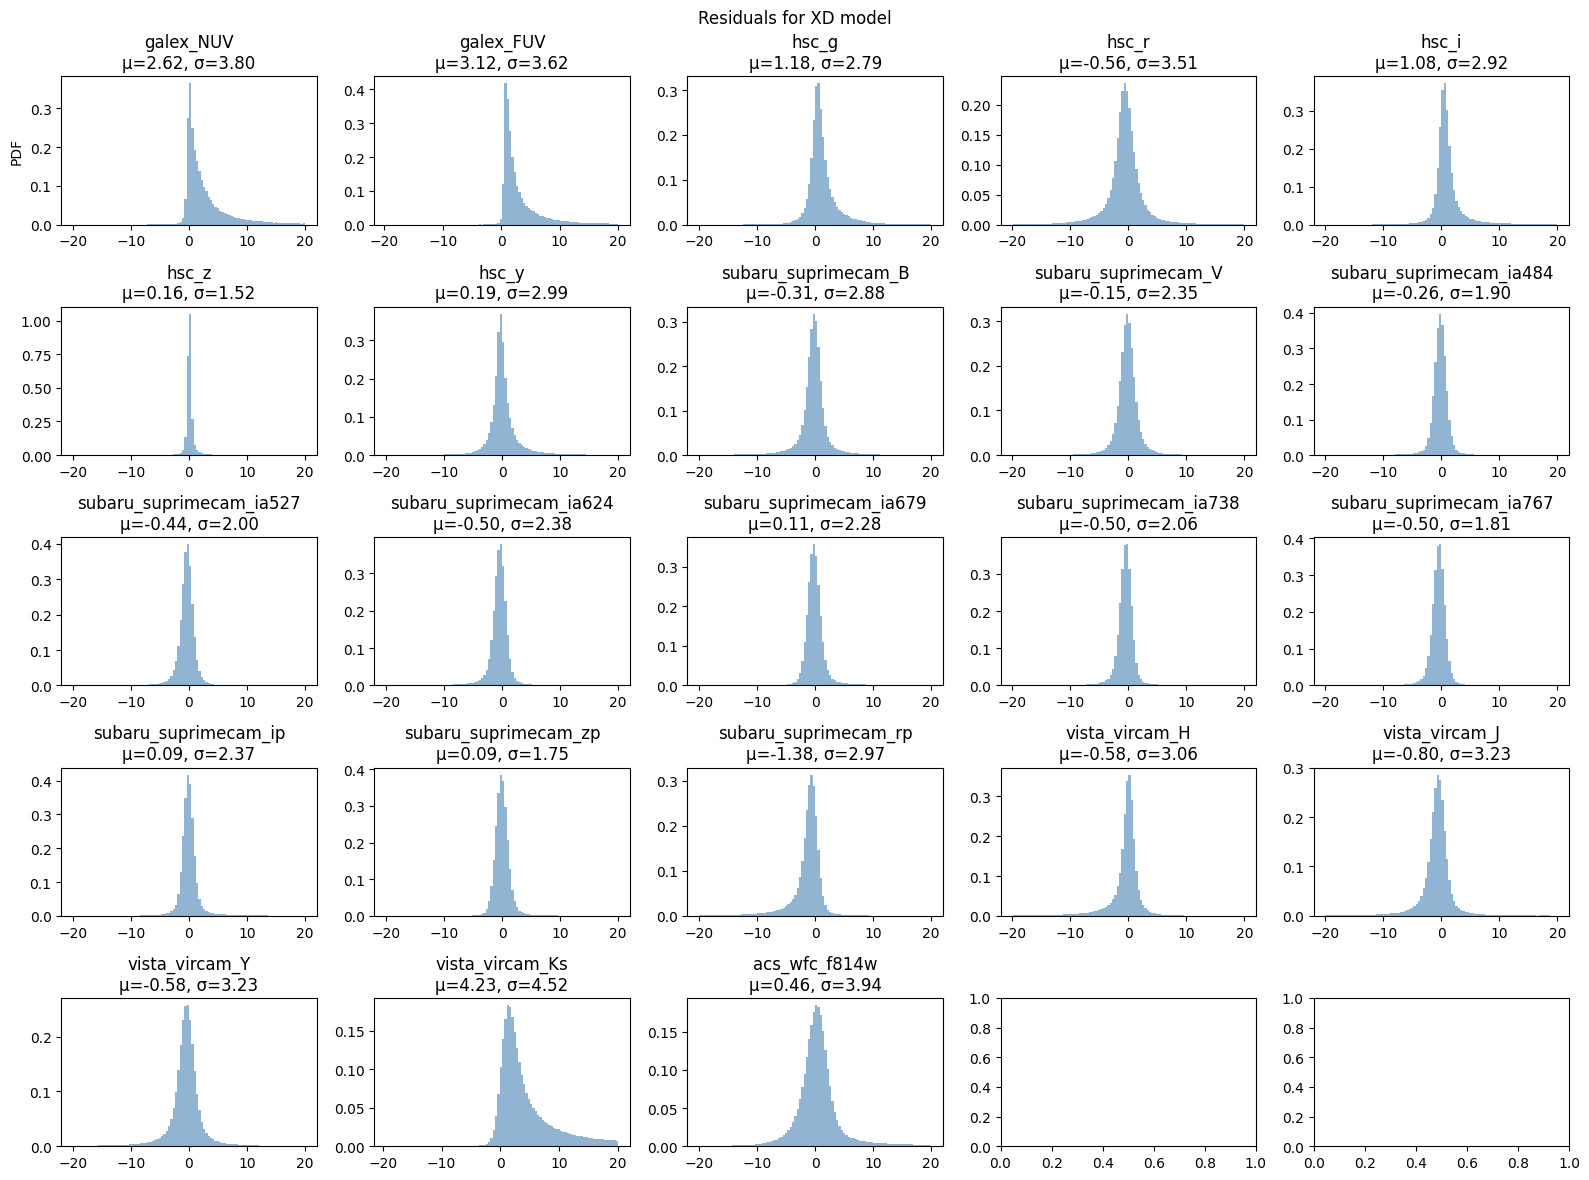

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()

n_gal, n_bands = df.shape

# Precompute once
A = X   # (n_bands, n_coeff)
model_flux_all = coeffs @ A   # (n_galaxies, n_bands)

for i in range(n_bands):
    data  = df.iloc[:, i].to_numpy()
    error = df_err.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error)
    data, error = data[mask], error[mask]
    model = model_flux_all[mask, i]

    # Normalized residuals
    r = (data - model) / error
    r_clip = r[np.abs(r) < 20]

    ax = axes[i]
    ax.hist(r_clip, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r_clip), np.std(r_clip)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for XD model')
plt.tight_layout()
plt.show()
